# Protein Classification: Data Analysis and Modeling
This notebook performs data analysis, preprocessing, model training with hyperparameter tuning, and saves the best model.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb

## 1. Load Data

In [2]:
# Load the training and testing datasets
train_df = pd.read_csv('data/proteinas_train.csv')
test_df = pd.read_csv('data/proteinas_test.csv')

print(f"Training data shape: {train_df.shape}")
print(f"Testing data shape: {test_df.shape}")
display(train_df.head())

Training data shape: (16000, 10)
Testing data shape: (4000, 10)


,ID_Proteína,Sequência,Massa_Molecular,Ponto_Isoelétrico,Hidrofobicidade,Carga_Total,Proporção_Polar,Proporção_Apolar,Comprimento_Sequência,Classe
0,TRAIN_P00001,GNMRFVLHDEETHWGTLRTTLNCVPSDIYTISGEDSLFWGMAHPFC...,20362.9468,4.866123,0.149425,-3,0.241379,0.408046,174,Estrutural
1,TRAIN_P00002,LFKMQCSFYLLYLAKEAASYQVSMNMLCYEWYNYVYQVTVILRLSR...,9328.7909,6.298636,0.217105,0,0.210526,0.513158,76,Estrutural
2,TRAIN_P00003,PAHLWPYWRFYVWIVFYGYHNPNYHFGMKEVKERPDCKNCTVAVLF...,17616.3852,8.458977,0.192568,8,0.141892,0.466216,148,Estrutural
3,TRAIN_P00004,GEAFSRPHCFACAATKKGFPWARMCCTTSMAMDGVQSKMHKSKHRF...,35244.2968,8.448340,0.160473,21,0.189189,0.408784,296,Estrutural
4,TRAIN_P00005,HYVFQGLMLHCGGYMITACGFGVIFPEQMTREGLIMHTARAHHFLI...,34557.9931,7.696306,0.140411,18,0.202055,0.380137,292,Receptora


## 2. Exploratory Data Analysis (EDA)

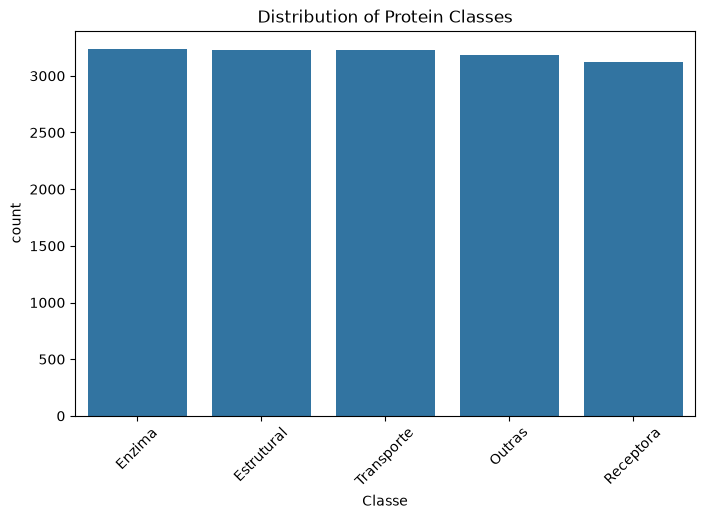

In [3]:
# Distribution of the target variable
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='Classe', order=train_df['Classe'].value_counts().index)
plt.title('Distribution of Protein Classes')
plt.xticks(rotation=45)
plt.show()

In [4]:
# Summary statistics of numerical features
numerical_cols = ['Massa_Molecular', 'Ponto_Isoelétrico', 'Hidrofobicidade', 
                  'Carga_Total', 'Proporção_Polar', 'Proporção_Apolar', 'Comprimento_Sequência']
train_df[numerical_cols].describe()

,Massa_Molecular,Ponto_Isoelétrico,Hidrofobicidade,Carga_Total,Proporção_Polar,Proporção_Apolar,Comprimento_Sequência
count,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,20708.209250,7.274537,0.149983,8.729938,0.200260,0.399930,174.033688
std,8678.439780,1.448253,0.027485,7.537891,0.033875,0.042192,72.920304
min,5463.212900,4.050028,0.014563,-20.000000,0.049180,0.200000,50.000000
25%,13165.853975,6.048970,0.132911,3.000000,0.178899,0.373376,111.000000
50%,20597.677000,7.196834,0.150000,8.000000,0.200000,0.400000,173.000000
75%,28193.961625,8.586190,0.167364,13.000000,0.221239,0.426573,237.000000
max,37588.751700,11.711987,0.284314,47.000000,0.380282,0.607843,300.000000


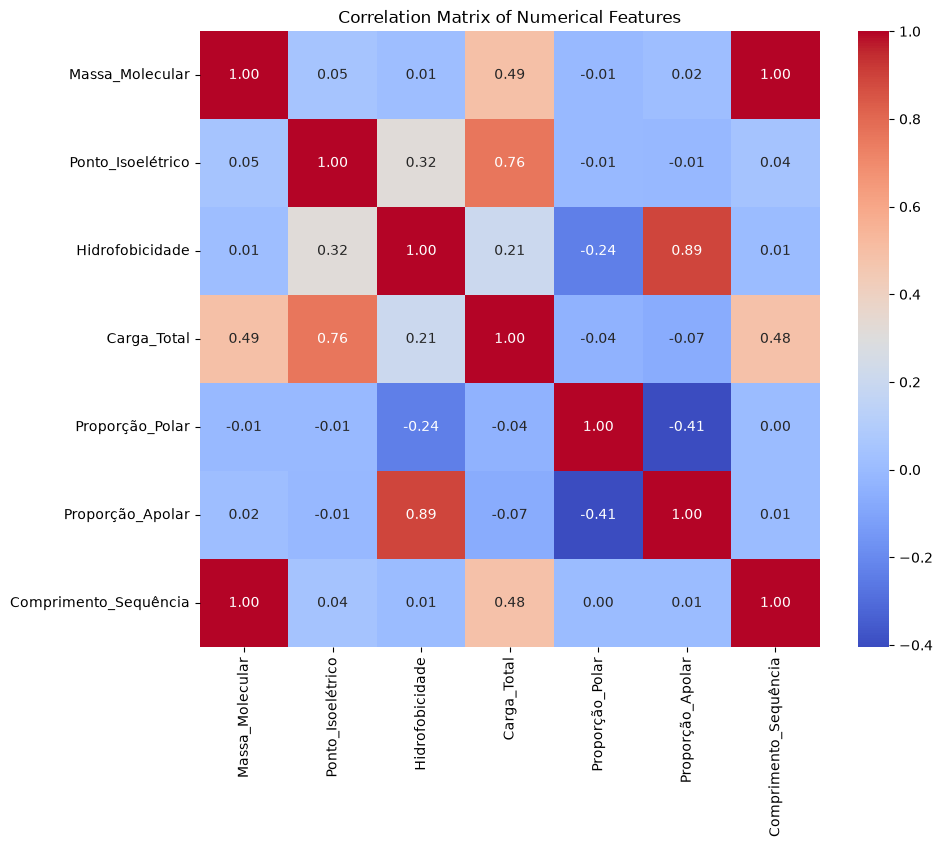

In [5]:
# Correlation matrix of numerical features
plt.figure(figsize=(10, 8))
corr_matrix = train_df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## 3. Data Preprocessing
We will extract k-mers from the protein sequence and combine them with the numerical features.

In [6]:
# Remove Comprimento_Sequência
numerical_cols = ['Massa_Molecular', 'Ponto_Isoelétrico', 'Hidrofobicidade', 
                  'Carga_Total', 'Proporção_Polar', 'Proporção_Apolar']
                  
# Define a function to extract k-mers (e.g., 3-mers) from sequences
def get_kmers(sequence, k=3):
    return " ".join([sequence[i:i+k] for i in range(len(sequence) - k + 1)])

# Apply k-mer extraction
train_df['kmers'] = train_df['Sequência'].apply(lambda x: get_kmers(x, k=3))
test_df['kmers'] = test_df['Sequência'].apply(lambda x: get_kmers(x, k=3))

# Separate features and target
X_train = train_df[numerical_cols + ['kmers']]
y_train = train_df['Classe']

X_test = test_df[numerical_cols + ['kmers']]
y_test = test_df['Classe']

# Encode target variable
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [7]:
# Build a ColumnTransformer for preprocessing
# 1. Scale numerical features
# 2. TF-IDF for sequence k-mers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('text', TfidfVectorizer(max_features=500), 'kmers')
    ])

# Transform the data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed training data shape: {X_train_processed.shape}")

Processed training data shape: (16000, 506)


## 4. Model Training and Hyperparameter Tuning
We will train Logistic Regression, Random Forest, and XGBoost, tuning their hyperparameters using RandomizedSearchCV.

In [8]:
# Define models and their hyperparameter grids
models = {
    'LogisticRegression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.1, 1.0, 10.0],
            'penalty': ['l2']
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5]
        }
    },
    'XGBoost': {
        'model': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5, 7]
        }
    }
}

best_models = {}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for model_name, config in models.items():
    print(f"Training and tuning {model_name}...")
    search = RandomizedSearchCV(
        config['model'], 
        param_distributions=config['params'], 
        n_iter=5, 
        cv=cv, 
        scoring='accuracy', 
        n_jobs=-1, 
        random_state=42,
        verbose=1
    )
    search.fit(X_train_processed, y_train_encoded)
    best_models[model_name] = search.best_estimator_
    print(f"Best params for {model_name}: {search.best_params_}")
    print(f"Best cross-validation accuracy: {search.best_score_:.4f}\n")

Training and tuning LogisticRegression...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best params for LogisticRegression: {'penalty': 'l2', 'C': 1.0}
Best cross-validation accuracy: 0.2010

Training and tuning RandomForest...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best params for RandomForest: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 10}
Best cross-validation accuracy: 0.2045

Training and tuning XGBoost...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best params for XGBoost: {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.01}
Best cross-validation accuracy: 0.2043



## 5. Model Evaluation

--- LogisticRegression Test Accuracy: 0.2067 ---
--- RandomForest Test Accuracy: 0.2135 ---
--- XGBoost Test Accuracy: 0.1970 ---

Overall Best Model: RandomForest with accuracy 0.2135

Classification Report for Best Model:
              precision    recall  f1-score   support

      Enzima       0.21      0.32      0.26       792
  Estrutural       0.22      0.30      0.26       863
      Outras       0.21      0.15      0.17       765
   Receptora       0.19      0.05      0.08       774
  Transporte       0.21      0.23      0.22       806

    accuracy                           0.21      4000
   macro avg       0.21      0.21      0.20      4000
weighted avg       0.21      0.21      0.20      4000



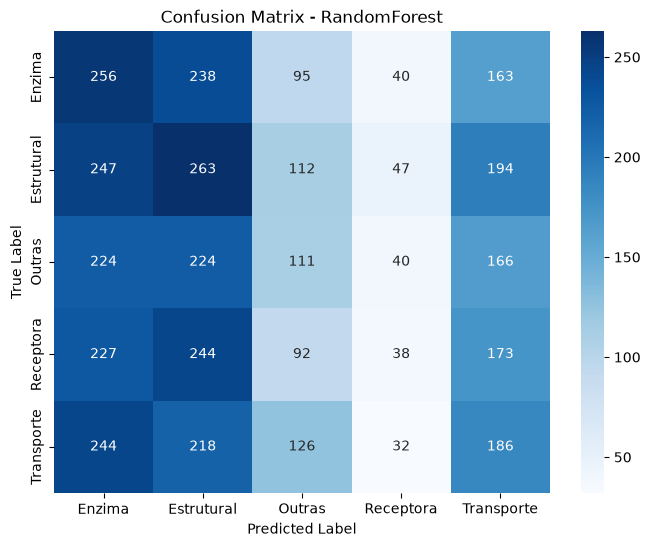

In [9]:
# Evaluate models on the training set (or test set if labels are available)
best_model_name = None
best_accuracy = 0
best_model = None

for model_name, model in best_models.items():
    y_pred = model.predict(X_test_processed)
    acc = accuracy_score(y_test_encoded, y_pred)
    print(f"--- {model_name} Test Accuracy: {acc:.4f} ---")
        
    if acc > best_accuracy:
        best_accuracy = acc
        best_model_name = model_name
        best_model = model

print(f"\nOverall Best Model: {best_model_name} with accuracy {best_accuracy:.4f}")

if y_test is not None:
    y_pred_best = best_model.predict(X_test_processed)
    print("\nClassification Report for Best Model:")
    print(classification_report(y_test_encoded, y_pred_best, target_names=le.classes_))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test_encoded, y_pred_best)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix - {best_model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


## 6. Save Best Model

In [10]:
# Create a pipeline that includes preprocessing and the best model
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])

# Save the pipeline and the label encoder
joblib.dump(final_pipeline, 'best_protein_classifier.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("Best model and label encoder saved successfully as 'best_protein_classifier.pkl' and 'label_encoder.pkl'.")
print("You can download these files to use the model for predictions.")

Best model and label encoder saved successfully as 'best_protein_classifier.pkl' and 'label_encoder.pkl'.
You can download these files to use the model for predictions.
